In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

/tmp/ipykernel_32870/3884926229.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
base_dir = '../data/s1/original/'

dfs = []
files = next(os.walk(base_dir))[2]

for file in files:
    dfs.append(pd.read_csv(os.path.join(base_dir, file), encoding='utf-8'))

In [3]:
original_df = pd.concat(dfs, ignore_index=True, sort=True)

                 x            y      cluster          _id
count  1000.000000  1000.000000  1000.000000  1000.000000
mean      0.641877     0.565991     2.154000   499.500000
std       0.174903     0.209603     0.933357   288.819436
min       0.328162     0.167528     1.000000     0.000000
25%       0.445686     0.307997     1.000000   249.750000
50%       0.624741     0.570947     2.000000   499.500000
75%       0.828927     0.783001     3.000000   749.250000
max       0.914913     0.880495     4.000000   999.000000
cluster
2    316
3    314
1    300
4     70
Name: count, dtype: int64
                 x            y      cluster          _id
count  1000.000000  1000.000000  1000.000000  1000.000000
mean      0.624774     0.435466     5.280000  1499.500000
std       0.290300     0.251822     0.948947   288.819436
min       0.093828     0.032593     4.000000  1000.000000
25%       0.335568     0.130371     5.000000  1249.750000
50%       0.833661     0.542231     5.000000  1499.500000
75

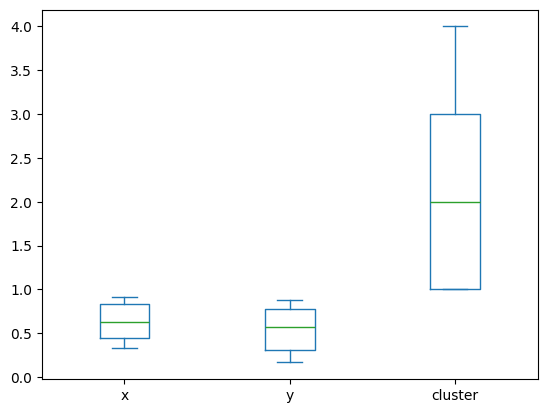

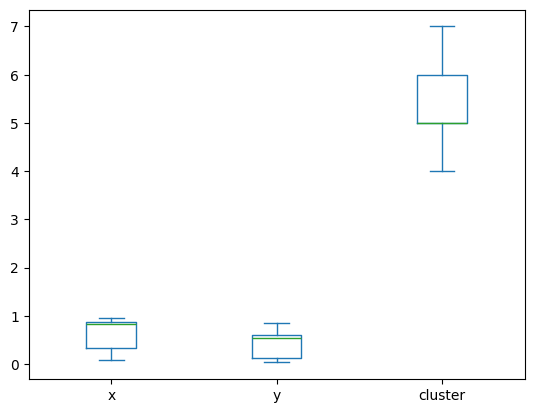

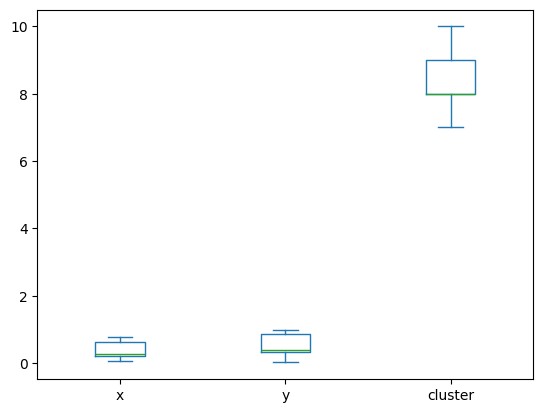

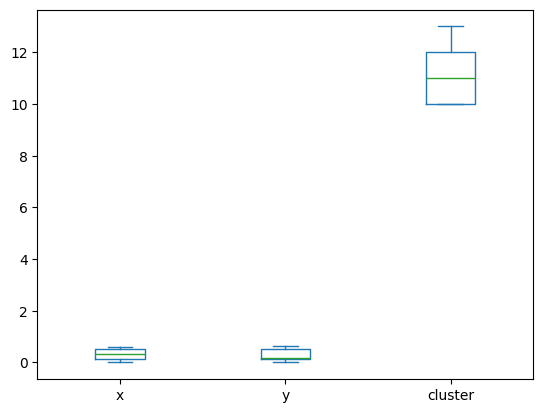

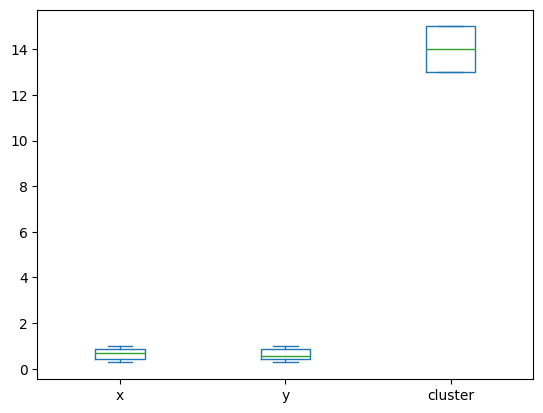

In [4]:
for df in dfs:
    print(df.describe())
    df[df.columns[0:-1]].plot.box()
    print(df['cluster'].value_counts())

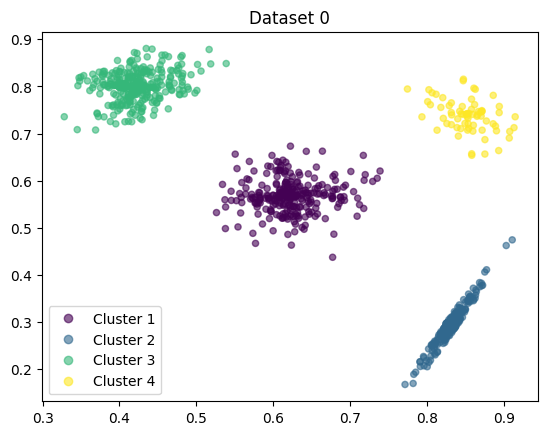

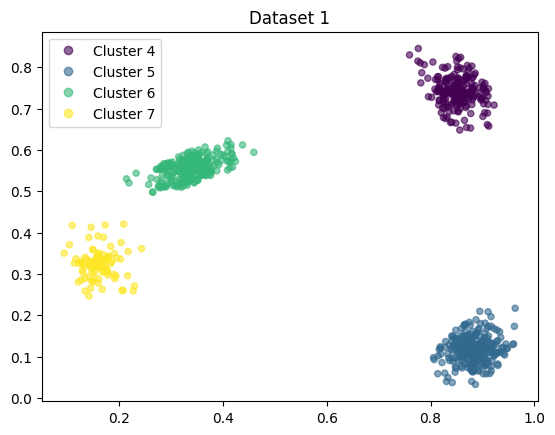

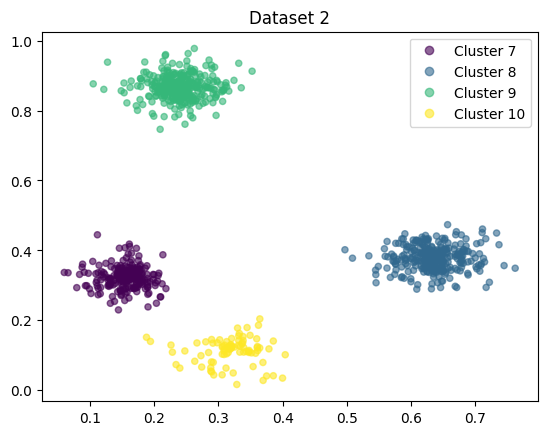

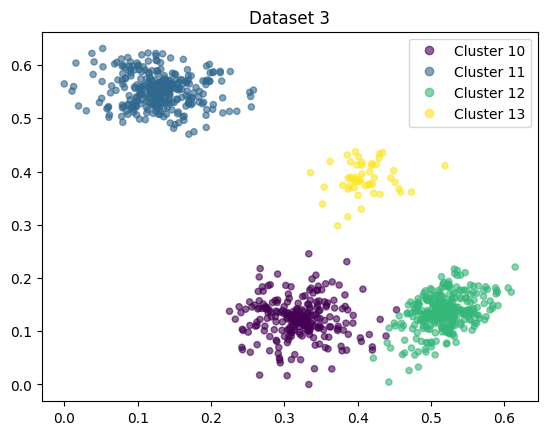

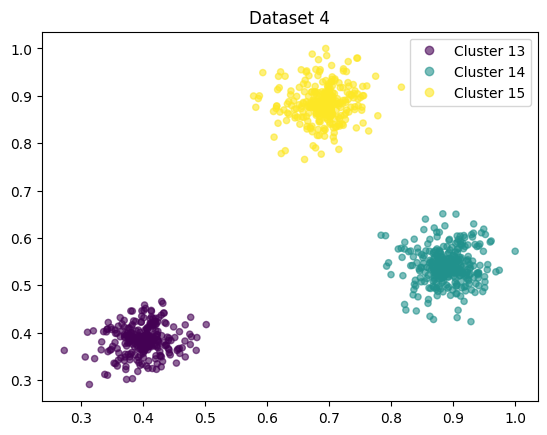

In [5]:
for index, df in enumerate(dfs):
    fig, ax = plt.subplots()
    scatter = plt.scatter(df["x"], df["y"], c=df['cluster'], alpha = 0.6, s=20)
    ax.legend(handles=scatter.legend_elements()[0], labels=map(lambda x: 'Cluster ' + str(x), df['cluster'].unique()))
    ax.set_title(f"Dataset {index}")

In [6]:
base_dir = '../data/s1/continuous/'

dfs = []
files = next(os.walk(base_dir))[2]

for file in files:
    df = pd.read_csv(os.path.join(base_dir, file), encoding='utf-8')
    dfs.append(df)


In [7]:
dfs

[            x         y  cluster   _id
 0    0.683912  0.543504        1     0
 1    0.685701  0.551136        1     1
 2    0.612810  0.570245        1     2
 3    0.635553  0.544047        1     3
 4    0.653693  0.605594        1     4
 ..        ...       ...      ...   ...
 990  0.692459  0.880537       15  4715
 991  0.738891  0.923848       15  4716
 992  0.694608  0.898216       15  4717
 993  0.700533  0.879635       15  4718
 994  0.592999  0.949029       15  4719
 
 [995 rows x 4 columns],
             x         y  cluster   _id
 0    0.709233  0.524571        1    60
 1    0.675758  0.567493        1    61
 2    0.552155  0.557577        1    62
 3    0.613070  0.529820        1    63
 4    0.630188  0.569369        1    64
 ..        ...       ...      ...   ...
 995  0.660287  0.765702       15  4785
 996  0.704558  0.934785       15  4786
 997  0.697501  0.920266       15  4787
 998  0.610206  0.867014       15  4788
 999  0.678168  0.790051       15  4789
 
 [1000 rows

In [8]:
def cluster_wise_f_measure(data):
    sum = 0
    unique_clusters_predicted = sorted(data['cluster'].unique())
    for cluster in unique_clusters_predicted:
    	predicted_cluster = data[data['cluster'] == cluster]
    	true_cluster = cluster_with_max_shared(predicted_cluster, data)
    	sum += f_measure(set(predicted_cluster['_id']), set(true_cluster['_id']))
    
    length = len(unique_clusters_predicted)
    return (sum / length)

def f_measure(pred, true):
    value = (2 * len(pred & true)) / (len(true) + len(pred))
    return value


def cluster_with_max_shared(predicted_cluster, data):
	predicted = set(predicted_cluster['_id'])
	true = data['actual_cluster'].unique()
	max_cluster = 0
	max_session = 0

	for label in true:
		cluster = data[data['actual_cluster'] == label]
		same_cluster = len(predicted & set(cluster['_id']))
		if same_cluster > max_cluster:
			max_cluster = same_cluster
			max_session = label
	return data[data['actual_cluster'] == max_session]

def cluster_wise_jaccard(data):
	sum = 0
	unique_clusters_predicted = sorted(data['cluster'].unique())
	for cluster in unique_clusters_predicted:
		predicted_cluster = data[data['cluster'] == cluster]
		true_cluster = cluster_with_max_shared(predicted_cluster, data)
		sum += jaccard_measure(set(predicted_cluster['_id']), set(true_cluster['_id']))

	length = len(unique_clusters_predicted)
	return (sum / length)


def jaccard_measure(y_true, y_pred):
    return (len(y_pred & y_true)) / (len(y_true) + len(y_pred) - len(y_true & y_pred))

In [45]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import numpy as np
import seaborn as sns

# base_dir = '../results/s1/original/tabular/30/'
# df = pd.read_csv(os.path.join(base_dir, 'final_clustering.csv'), encoding='utf-8')
# df = df[df['is_included']==True]

result_metrics = {}

def eda_clustering(window=30, data_type='original', is_included=False, num_segments = 4):
    print(f"window: {window}")
    base_dir = f'../results/s1/{data_type}/tabular/{window}/'
    df = pd.read_csv(os.path.join(base_dir, 'final_clustering.csv'), encoding='utf-8')
    df = df[df['segment']<=num_segments]
    # print(df.shape)
    if is_included:
        df = df[df['is_included']==True]
    
    df = df.rename(columns={'ids': '_id', 'target': 'actual_cluster'})
    # print(df.head())

    # palette = sns.color_palette('hls', n_colors=len(set(df['cluster'])))
    # sns.scatterplot(x=df['x'], y=df['y'], hue=df['cluster'], palette=palette)

    # plt.show()

    from sklearn.metrics import pairwise_distances,silhouette_score

    def calculate_distances(data):
        return pairwise_distances(data,data)

    print(df['cluster'].unique())
    distances = calculate_distances(df[df.columns[:-6]].to_numpy(copy=True))
    if len(df['cluster'].unique()) > 1:
        SI = silhouette_score(distances, df['cluster'])
    else:
        SI = None
    F1 = cluster_wise_f_measure(df)
    JI = cluster_wise_jaccard(df)
    # print(SI)
    # print(F1)
    # print(JI)

    result_metrics[window] = [SI, F1, JI, df['cluster'].unique()]


In [56]:
for window in [3, 4, 6, 8, 12, 24, 30, 32, 48]:
    eda_clustering(window=window, data_type='original', is_included=False, num_segments=4)

results_df = pd.DataFrame(result_metrics).T
results_df.columns = ['SI', 'F1', 'JI', 'cluster_count']
results_df

window: 3
[53 -1 22 24 26 27 30]
window: 4
[15 -1 19 17]


window: 6
[18 -1 16]
window: 8
[ 6 -1  5]
window: 12
[ 6  5 -1]
window: 24
[ 1  2  5 -1  6  8  9 10 11]
window: 30
[ 8  5 -1]
window: 32
[ 9  5 -1]
window: 48
[ 8  5 -1]


,SI,F1,JI,cluster_count
3,-0.172235,0.156605,0.087518,"[53, -1, 22, 24, 26, 27, 30]"
4,-0.111081,0.272617,0.171728,"[15, -1, 19, 17]"
6,-0.039471,0.254439,0.145863,"[18, -1, 16]"
8,0.129395,0.507678,0.425849,"[6, -1, 5]"
12,0.13027,0.506346,0.424812,"[6, 5, -1]"
24,0.215806,0.829775,0.764003,"[1, 2, 5, -1, 6, 8, 9, 10, 11]"
30,0.09836,0.492138,0.406677,"[8, 5, -1]"
32,0.08887,0.483691,0.393182,"[9, 5, -1]"
48,0.090087,0.451951,0.342809,"[8, 5, -1]"


window: 3
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504       53         True               1        0      -1   
1  0.685701  0.551136       53         True               1        0      -1   
2  0.612810  0.570245       53         True               1        0      -1   
3  0.635553  0.544047       53         True               1        0      -1   
4  0.653693  0.605594       53         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


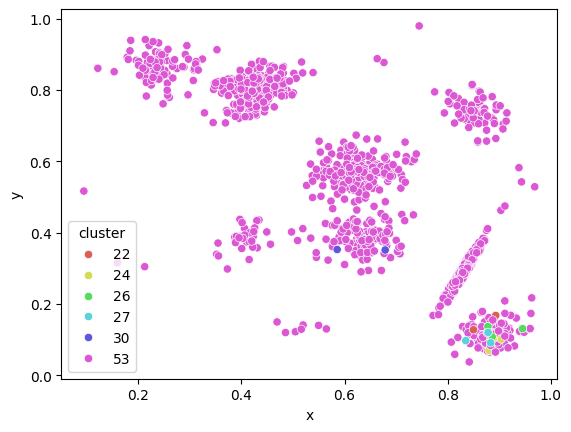

[53 22 24 26 27 30]
-0.2997915164434644
0.09122173204190015
0.0524527463808534
window: 4
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504       15         True               1        0      -1   
1  0.685701  0.551136       15         True               1        0      -1   
2  0.612810  0.570245       15         True               1        0      -1   
3  0.635553  0.544047       15         True               1        0      -1   
4  0.653693  0.605594       15         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


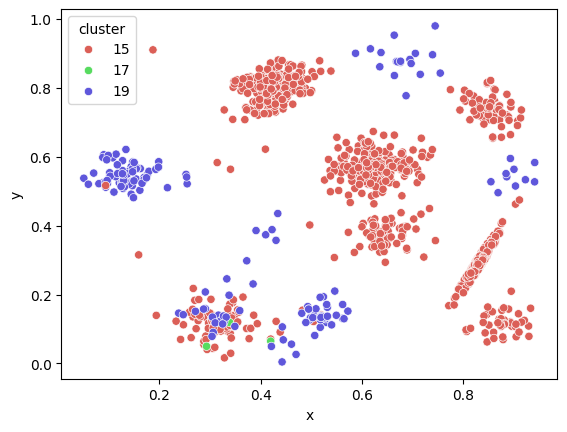

[15 19 17]
0.08096236750615547
0.35563280358301325
0.2381101353877785
window: 6
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504       18         True               1        0      -1   
1  0.685701  0.551136       18         True               1        0      -1   
2  0.612810  0.570245       18         True               1        0      -1   
3  0.635553  0.544047       18         True               1        0      -1   
4  0.653693  0.605594       18         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


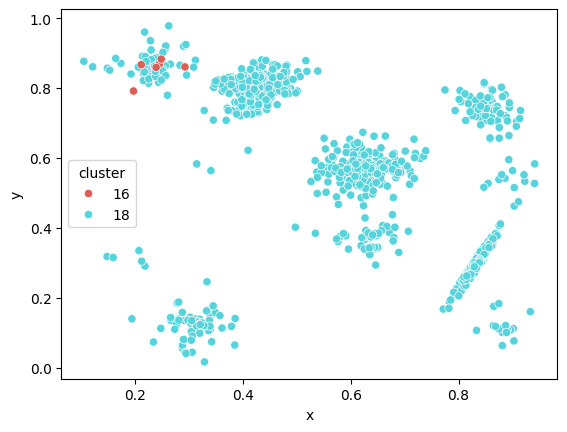

[18 16]
0.11817052989285222
0.28959965187119235
0.17538875598086123
window: 8
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504        6         True               1        0      -1   
1  0.685701  0.551136        6         True               1        0      -1   
2  0.612810  0.570245        6         True               1        0      -1   
3  0.635553  0.544047        6         True               1        0      -1   
4  0.653693  0.605594        6         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


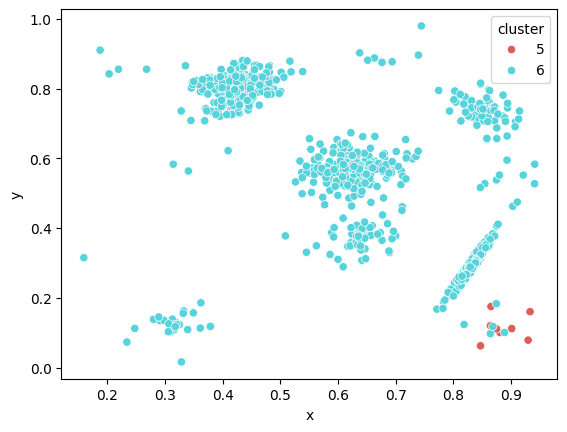

[6 5]
0.19450233111361587
0.6022408963585434
0.4497786386275595
window: 12
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504        6         True               1        0      -1   
1  0.685701  0.551136        6         True               1        0      -1   
2  0.612810  0.570245        6         True               1        0      -1   
3  0.635553  0.544047        6         True               1        0      -1   
4  0.653693  0.605594        6         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


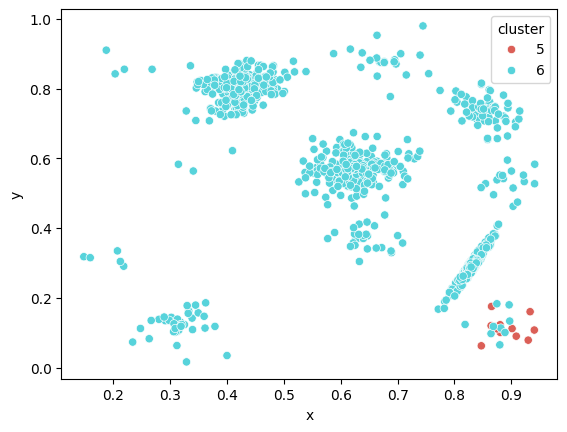

[6 5]
0.19016427329507649
0.5836920739427703
0.42678571428571427
window: 24
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504        1         True               1        0      -1   
1  0.685701  0.551136        1         True               1        0      -1   
2  0.612810  0.570245        1         True               1        0      -1   
3  0.635553  0.544047        1         True               1        0      -1   
4  0.653693  0.605594        1         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


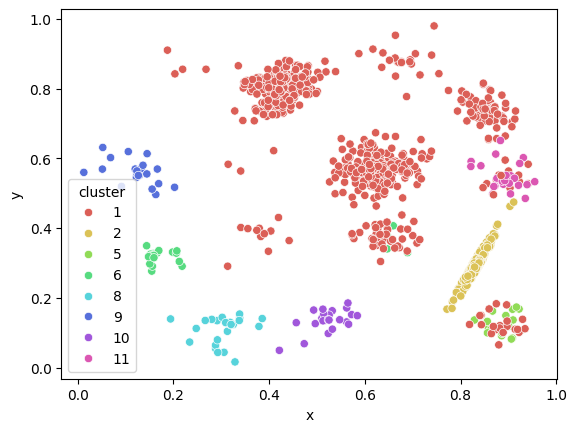

[ 1  2  5  6  8  9 10 11]
0.2893139867452536
0.8576039209247618
0.782974109714585
window: 30
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504        8         True               1        0      -1   
1  0.685701  0.551136        8         True               1        0      -1   
2  0.612810  0.570245        8         True               1        0      -1   
3  0.635553  0.544047        8         True               1        0      -1   
4  0.653693  0.605594        8         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


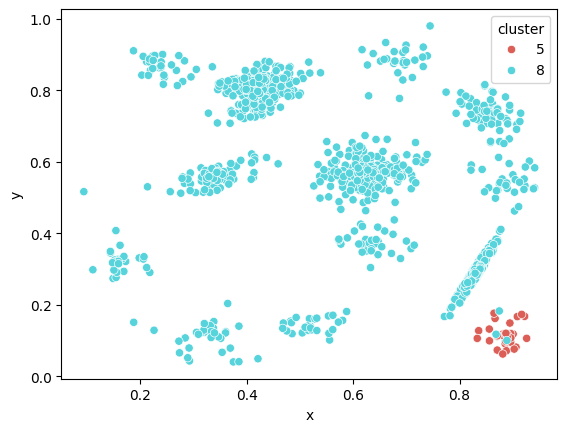

[8 5]
0.2043025318560461
0.6717350306459218
0.5760839160839161
window: 32
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504        9         True               1        0      -1   
1  0.685701  0.551136        9         True               1        0      -1   
2  0.612810  0.570245        9         True               1        0      -1   
3  0.635553  0.544047        9         True               1        0      -1   
4  0.653693  0.605594        9         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


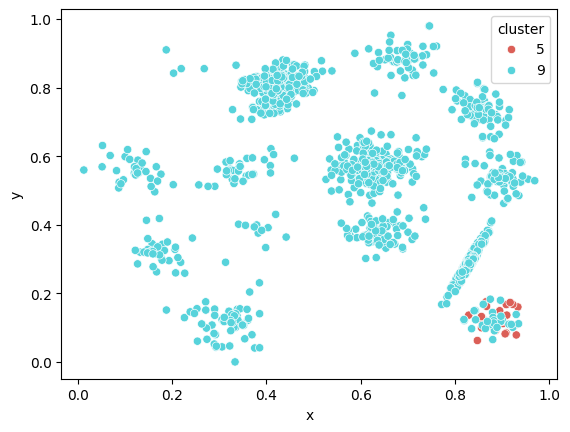

[9 5]
0.16524297536973753
0.5265340584568775
0.37387700287116793
window: 48
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504        8         True               1        0      -1   
1  0.685701  0.551136        8         True               1        0      -1   
2  0.612810  0.570245        8         True               1        0      -1   
3  0.635553  0.544047        8         True               1        0      -1   
4  0.653693  0.605594        8         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


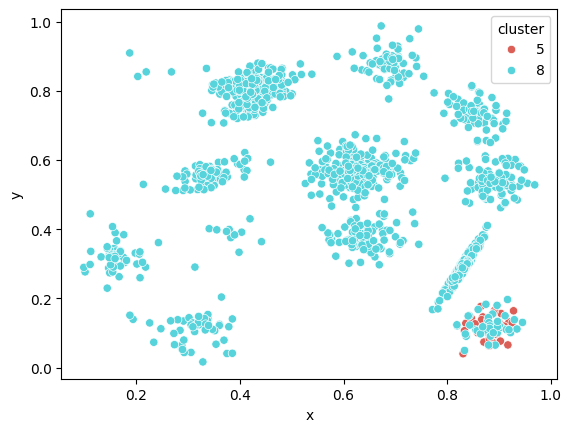

[8 5]
0.1861787572968466
0.5117921262749804
0.3614676574902888


,SI,F1,JI,cluster_count
3,-0.299792,0.091222,0.052453,"[53, 22, 24, 26, 27, 30]"
4,0.080962,0.355633,0.23811,"[15, 19, 17]"
6,0.118171,0.2896,0.175389,"[18, 16]"
8,0.194502,0.602241,0.449779,"[6, 5]"
12,0.190164,0.583692,0.426786,"[6, 5]"
24,0.289314,0.857604,0.782974,"[1, 2, 5, 6, 8, 9, 10, 11]"
30,0.204303,0.671735,0.576084,"[8, 5]"
32,0.165243,0.526534,0.373877,"[9, 5]"
48,0.186179,0.511792,0.361468,"[8, 5]"


In [19]:
for window in [3, 4, 6, 8, 12, 24, 30, 32, 48]:
    eda_clustering(window=window, data_type='original', is_included=True)

results_df = pd.DataFrame(result_metrics).T
results_df.columns = ['SI', 'F1', 'JI', 'cluster_count']
results_df

window: 3
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504       16         True               1        0      -1   
1  0.685701  0.551136       16         True               1        0      -1   
2  0.612810  0.570245       16         True               1        0      -1   
3  0.635553  0.544047       16         True               1        0      -1   
4  0.653693  0.605594       16         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


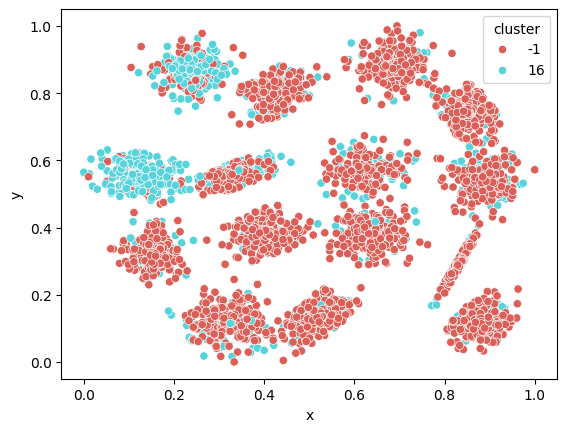

[16 -1]
0.025187202972345005
0.19733121417366273
0.11005737945424315
window: 4
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504       21         True               1        0      -1   
1  0.685701  0.551136       21         True               1        0      -1   
2  0.612810  0.570245       21         True               1        0      -1   
3  0.635553  0.544047       21         True               1        0      -1   
4  0.653693  0.605594       21         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


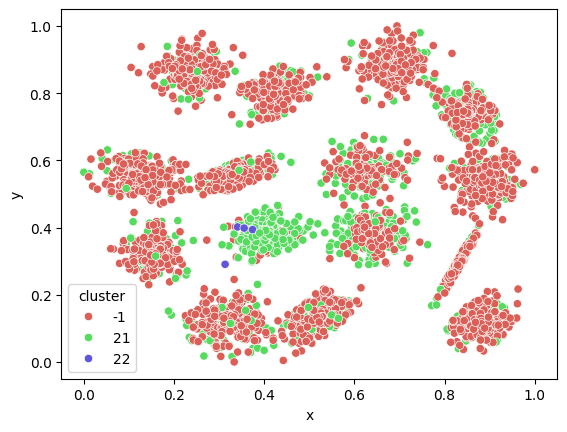

[21 -1 22]
-0.1947940648658607
0.1414380498822298
0.07848523332374549
window: 6
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504       10         True               1        0      -1   
1  0.685701  0.551136       10         True               1        0      -1   
2  0.612810  0.570245       10         True               1        0      -1   
3  0.635553  0.544047       10         True               1        0      -1   
4  0.653693  0.605594       10         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


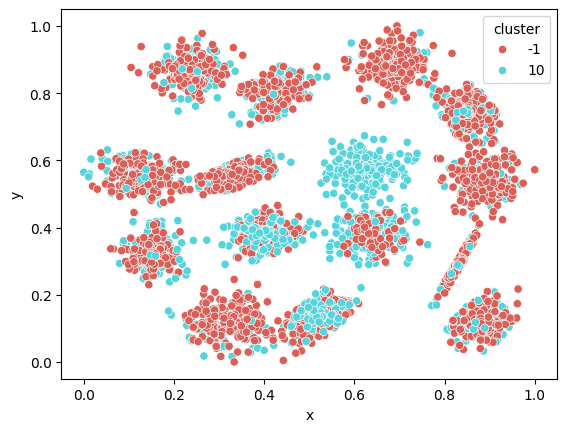

[10 -1]
0.01839706867188266
0.20538470377813467
0.11447192240270104
window: 8
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504       21         True               1        0      -1   
1  0.685701  0.551136       21         True               1        0      -1   
2  0.612810  0.570245       21         True               1        0      -1   
3  0.635553  0.544047       21         True               1        0      -1   
4  0.653693  0.605594       21         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


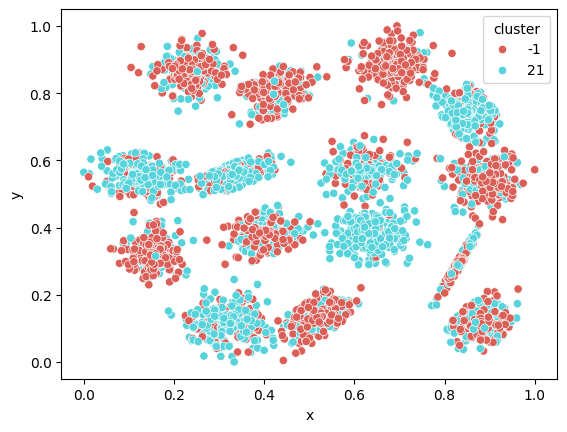

[21 -1]
0.015298885272624956
0.2129049627140659
0.11915226199979995
window: 12
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504       20         True               1        0      -1   
1  0.685701  0.551136       20         True               1        0      -1   
2  0.612810  0.570245       20         True               1        0      -1   
3  0.635553  0.544047       20         True               1        0      -1   
4  0.653693  0.605594       20         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


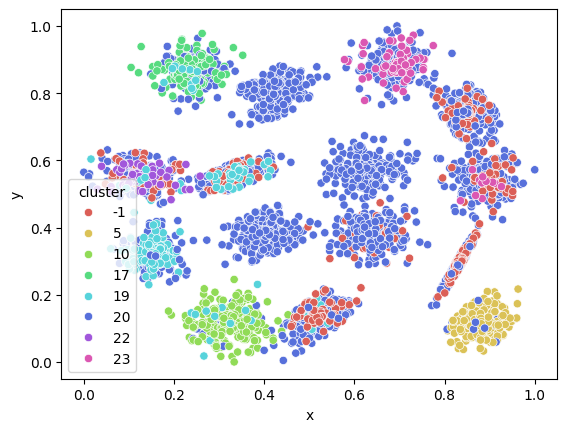

[20  5 10 17 -1 19 22 23]
-0.1772646202868472
0.5182397261884988
0.4097811012233248
window: 24
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504        1         True               1        0      -1   
1  0.685701  0.551136        1         True               1        0      -1   
2  0.612810  0.570245        1         True               1        0      -1   
3  0.635553  0.544047        1         True               1        0      -1   
4  0.653693  0.605594        1         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


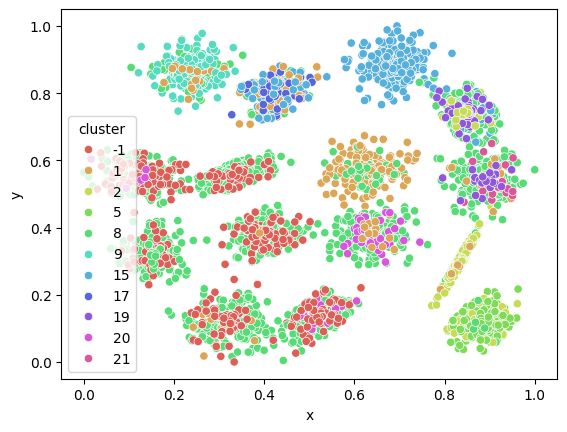

[ 1  2  8  5  9 15 17 -1 19 20 21]
-0.11776644018011007
0.5020421450201866
0.39045287352710917
window: 30
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504       13         True               1        0      -1   
1  0.685701  0.551136       13         True               1        0      -1   
2  0.612810  0.570245       13         True               1        0      -1   
3  0.635553  0.544047       13         True               1        0      -1   
4  0.653693  0.605594       13         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


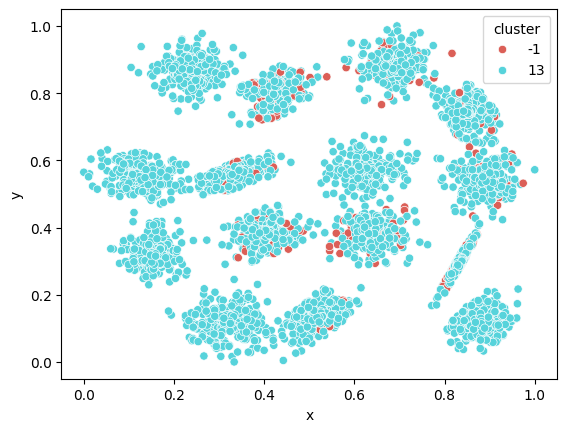

[13 -1]
-0.015362395317135246
0.16031507642245896
0.08726076370696828
window: 32
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504       14         True               1        0      -1   
1  0.685701  0.551136       14         True               1        0      -1   
2  0.612810  0.570245       14         True               1        0      -1   
3  0.635553  0.544047       14         True               1        0      -1   
4  0.653693  0.605594       14         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


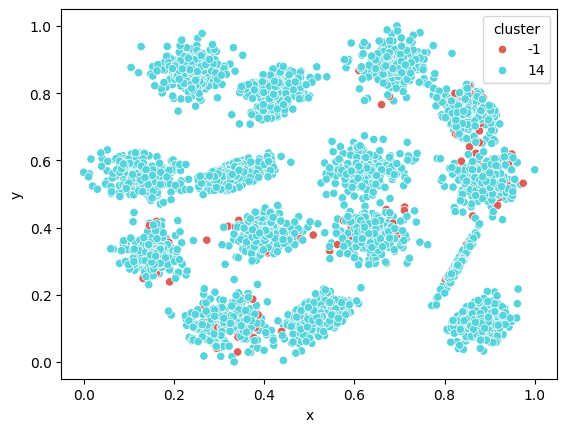

[14 -1]
-0.011260409110912906
0.17286776269221282
0.09502725737100737
window: 48
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504       12         True               1        0      -1   
1  0.685701  0.551136       12         True               1        0      -1   
2  0.612810  0.570245       12         True               1        0      -1   
3  0.635553  0.544047       12         True               1        0      -1   
4  0.653693  0.605594       12         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


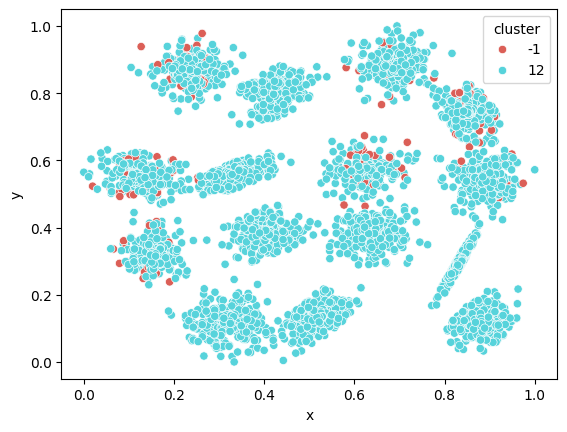

[12 -1]
0.030845804436222375
0.14612647028235
0.0788365021256495


,SI,F1,JI,cluster_count
3,0.025187,0.197331,0.110057,"[16, -1]"
4,-0.194794,0.141438,0.078485,"[21, -1, 22]"
6,0.018397,0.205385,0.114472,"[10, -1]"
8,0.015299,0.212905,0.119152,"[21, -1]"
12,-0.177265,0.51824,0.409781,"[20, 5, 10, 17, -1, 19, 22, 23]"
24,-0.117766,0.502042,0.390453,"[1, 2, 8, 5, 9, 15, 17, -1, 19, 20, 21]"
30,-0.015362,0.160315,0.087261,"[13, -1]"
32,-0.01126,0.172868,0.095027,"[14, -1]"
48,0.030846,0.146126,0.078837,"[12, -1]"


In [21]:
for window in [3, 4, 6, 8, 12, 24, 30, 32, 48]:
    eda_clustering(window=window, data_type='continuous', is_included=False)

results_df = pd.DataFrame(result_metrics).T
results_df.columns = ['SI', 'F1', 'JI', 'cluster_count']
results_df

window: 3
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504       16         True               1        0      -1   
1  0.685701  0.551136       16         True               1        0      -1   
2  0.612810  0.570245       16         True               1        0      -1   
3  0.635553  0.544047       16         True               1        0      -1   
4  0.653693  0.605594       16         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


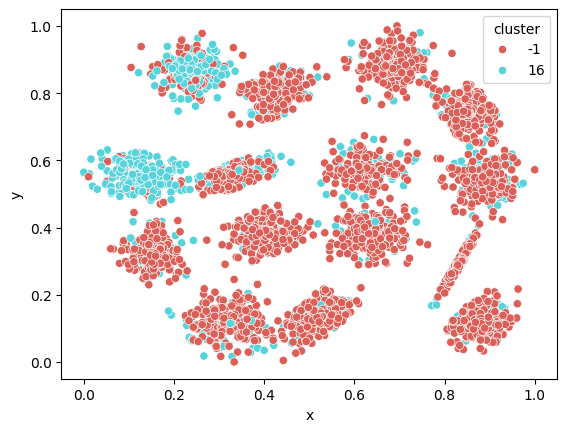

[16 -1]
0.025187202972345005
0.19733121417366273
0.11005737945424315
window: 4
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504       21         True               1        0      -1   
1  0.685701  0.551136       21         True               1        0      -1   
2  0.612810  0.570245       21         True               1        0      -1   
3  0.635553  0.544047       21         True               1        0      -1   
4  0.653693  0.605594       21         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


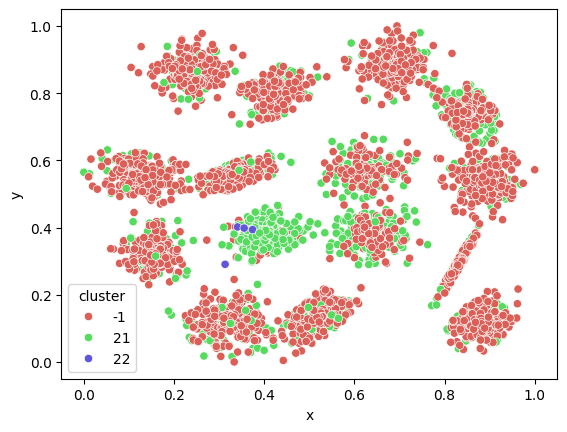

[21 -1 22]
-0.1947940648658607
0.1414380498822298
0.07848523332374549
window: 6
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504       10         True               1        0      -1   
1  0.685701  0.551136       10         True               1        0      -1   
2  0.612810  0.570245       10         True               1        0      -1   
3  0.635553  0.544047       10         True               1        0      -1   
4  0.653693  0.605594       10         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


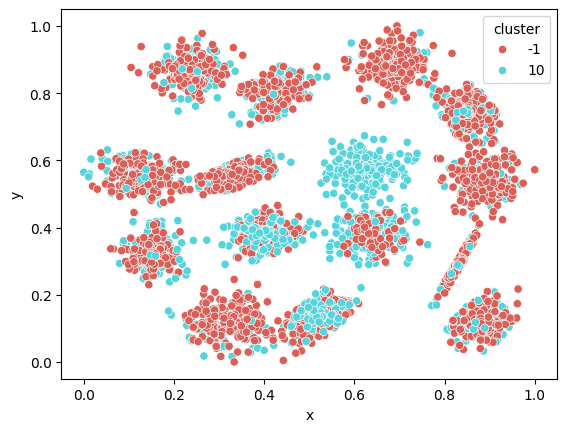

[10 -1]
0.01839706867188266
0.20538470377813467
0.11447192240270104
window: 8
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504       21         True               1        0      -1   
1  0.685701  0.551136       21         True               1        0      -1   
2  0.612810  0.570245       21         True               1        0      -1   
3  0.635553  0.544047       21         True               1        0      -1   
4  0.653693  0.605594       21         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


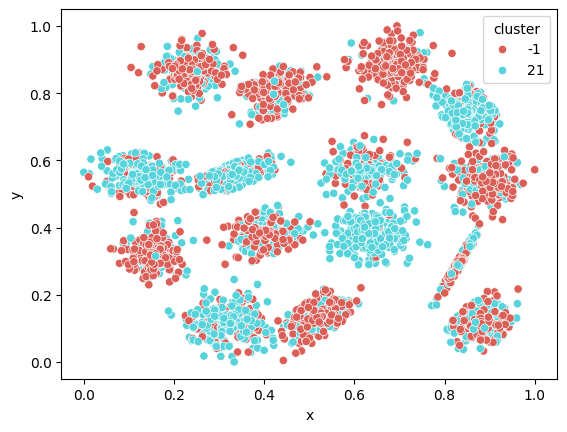

[21 -1]
0.015298885272624956
0.2129049627140659
0.11915226199979995
window: 12
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504       20         True               1        0      -1   
1  0.685701  0.551136       20         True               1        0      -1   
2  0.612810  0.570245       20         True               1        0      -1   
3  0.635553  0.544047       20         True               1        0      -1   
4  0.653693  0.605594       20         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


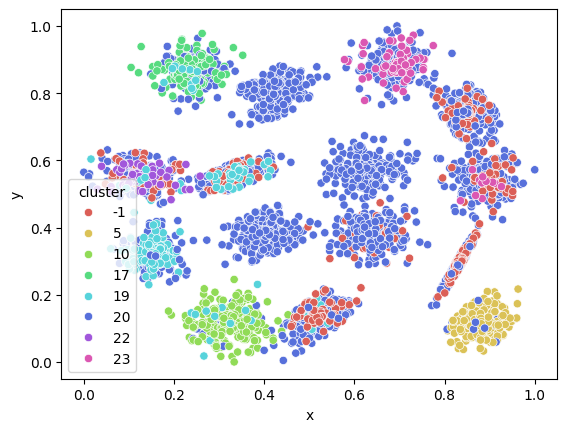

[20  5 10 17 -1 19 22 23]
-0.1772646202868472
0.5182397261884988
0.4097811012233248
window: 24
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504        1         True               1        0      -1   
1  0.685701  0.551136        1         True               1        0      -1   
2  0.612810  0.570245        1         True               1        0      -1   
3  0.635553  0.544047        1         True               1        0      -1   
4  0.653693  0.605594        1         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


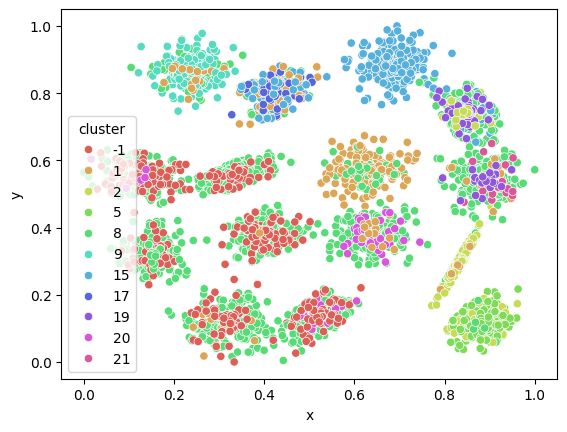

[ 1  2  8  5  9 15 17 -1 19 20 21]
-0.11776644018011007
0.5020421450201866
0.39045287352710917
window: 30
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504       13         True               1        0      -1   
1  0.685701  0.551136       13         True               1        0      -1   
2  0.612810  0.570245       13         True               1        0      -1   
3  0.635553  0.544047       13         True               1        0      -1   
4  0.653693  0.605594       13         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


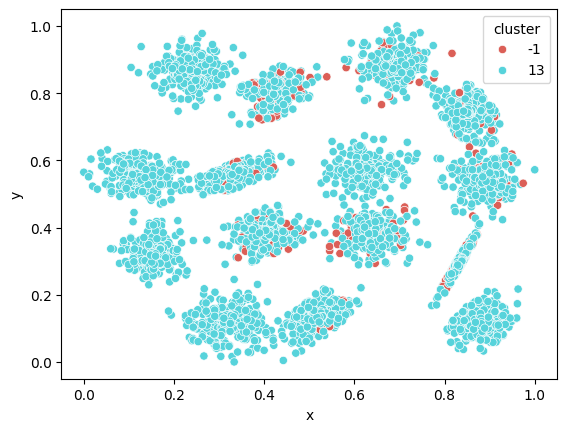

[13 -1]
-0.015362395317135246
0.16031507642245896
0.08726076370696828
window: 32
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504       14         True               1        0      -1   
1  0.685701  0.551136       14         True               1        0      -1   
2  0.612810  0.570245       14         True               1        0      -1   
3  0.635553  0.544047       14         True               1        0      -1   
4  0.653693  0.605594       14         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


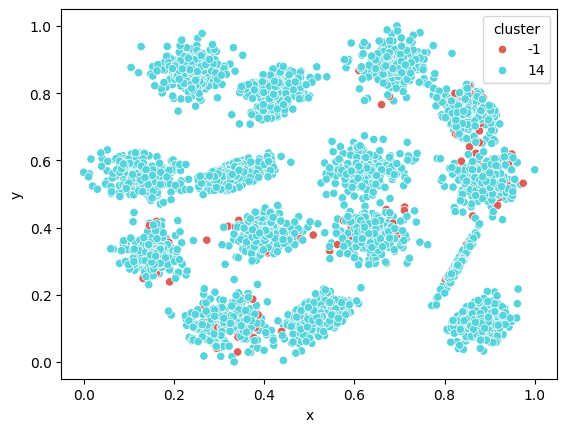

[14 -1]
-0.011260409110912906
0.17286776269221282
0.09502725737100737
window: 48
          x         y  cluster  is_included  actual_cluster  segment  stream  \
0  0.683912  0.543504       12         True               1        0      -1   
1  0.685701  0.551136       12         True               1        0      -1   
2  0.612810  0.570245       12         True               1        0      -1   
3  0.635553  0.544047       12         True               1        0      -1   
4  0.653693  0.605594       12         True               1        0      -1   

   _id  
0    0  
1    1  
2    2  
3    3  
4    4  


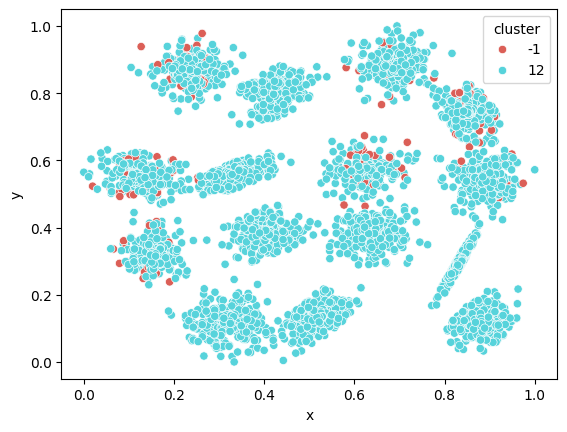

[12 -1]
0.030845804436222375
0.14612647028235
0.0788365021256495


,SI,F1,JI,cluster_count
3,0.025187,0.197331,0.110057,"[16, -1]"
4,-0.194794,0.141438,0.078485,"[21, -1, 22]"
6,0.018397,0.205385,0.114472,"[10, -1]"
8,0.015299,0.212905,0.119152,"[21, -1]"
12,-0.177265,0.51824,0.409781,"[20, 5, 10, 17, -1, 19, 22, 23]"
24,-0.117766,0.502042,0.390453,"[1, 2, 8, 5, 9, 15, 17, -1, 19, 20, 21]"
30,-0.015362,0.160315,0.087261,"[13, -1]"
32,-0.01126,0.172868,0.095027,"[14, -1]"
48,0.030846,0.146126,0.078837,"[12, -1]"


In [22]:
for window in [3, 4, 6, 8, 12, 24, 30, 32, 48]:
    eda_clustering(window=window, data_type='continuous_previous', is_included=False)

results_df = pd.DataFrame(result_metrics).T
results_df.columns = ['SI', 'F1', 'JI', 'cluster_count']
results_df